In [2]:
"""
Makine Öğrenmesi Final Ödev
Proje: Akıllı Şebeke (Smart Grid) Kararlılık Tahmini
Amaç: Veri okuma, ön işleme, öznitelik mühendisliği, hiperparametre ayarlama ve model eğitimi
      (Sınıflandırma) adımlarını uçtan uca bir Python projesi olarak uygulamak.
Kullanılan Kütüphaneler: pandas, numpy, scikit-learn, matplotlib, seaborn
"""

import pandas as pd
import numpy as np

# ==========================================
# Adım 2 & 3: Veri Setini Okuma ve Hedef Değişkeni Belirleme
# ==========================================
# Veri setini yüklüyoruz (Dosyanın Colab'a yüklendiğinden emin olun)
df = pd.read_csv('Data_for_UCI_named.csv')

print("--- Adım 2 & 3: Proje Tanımı ve Hedef ---")
print("Problem Türü: Sınıflandırma (Classification)")
print("Açıklama: Bu proje, akıllı elektrik şebekelerindeki güç dengesi (p) ve tepki süresi (tau) ")
print("gibi parametrelere dayanarak şebekenin 'kararlı' veya 'kararsız' olma durumunu tahmin eder.\n")

# Veri setinde 'stab' sayısal, 'stabf' ise kategorik hedef değişkendir.
# Doğrudan sınıflandırma yapacağımız için modelde sızıntıyı (data leakage) önlemek adına 'stab' sütununu siliyoruz.
if 'stab' in df.columns:
    df = df.drop('stab', axis=1)

hedef_degisken = 'stabf'
print(f"Hedef Değişken: {hedef_degisken}")

# Modellerin anlayabilmesi için kategorik hedef değişkeni sayısal değerlere dönüştürüyoruz (unstable=0, stable=1)
df['stabf'] = df['stabf'].map({'unstable': 0, 'stable': 1})
print("Hedef değişken sayısal formata (0 ve 1) dönüştürüldü.\n")

# ==========================================
# Adım 4: Veri Setinin İlk İncelemesi
# ==========================================
print("--- Adım 4: Veri Setinin Temel İncelemesi ---")
print(f"Toplam Satır: {df.shape[0]}")
print(f"Toplam Sütun: {df.shape[1]}\n")

print("Veri Tipleri:")
print(df.dtypes, "\n")

print("İlk 5 Satır:")
print(df.head(), "\n")

print("Temel İstatistikler:")
print(df.describe().T)

--- Adım 2 & 3: Proje Tanımı ve Hedef ---
Problem Türü: Sınıflandırma (Classification)
Açıklama: Bu proje, akıllı elektrik şebekelerindeki güç dengesi (p) ve tepki süresi (tau) 
gibi parametrelere dayanarak şebekenin 'kararlı' veya 'kararsız' olma durumunu tahmin eder.

Hedef Değişken: stabf
Hedef değişken sayısal formata (0 ve 1) dönüştürüldü.

--- Adım 4: Veri Setinin Temel İncelemesi ---
Toplam Satır: 10000
Toplam Sütun: 13

Veri Tipleri:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stabf      int64
dtype: object 

İlk 5 Satır:
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Adım 5: Eksik Değer Kontrolü
# ==========================================
print("--- Adım 5: Eksik Değer Kontrolü ---")
eksik_degerler = df.isnull().sum().sum()
if eksik_degerler == 0:
    print("Veri setinde eksik değer bulunmamaktadır.\n")
else:
    print(f"Veri setinde toplam {eksik_degerler} eksik değer bulundu. Temizleniyor...")
    df = df.dropna()

# ==========================================
# Adım 9: Öznitelik Üretme (Feature Engineering)
# ==========================================
print("--- Adım 9: Öznitelik Üretme ---")
# 1. Yeni Öznitelik: Tüketicilerin toplam tepki süresi
df['toplam_tepki_suresi'] = df['tau2'] + df['tau3'] + df['tau4']
# 2. Yeni Öznitelik: Tüketicilerin ortalama fiyat esnekliği
df['ortalama_fiyat_esnekligi'] = (df['g2'] + df['g3'] + df['g4']) / 3
print("İki yeni öznitelik başarıyla üretildi: 'toplam_tepki_suresi' ve 'ortalama_fiyat_esnekligi'\n")

# ==========================================
# Adım 7: Aykırı Değer İncelemesi (Outlier Analysis)
# ==========================================
print("--- Adım 7: Aykırı Değer Analizi ---")
# Aykırı değerleri IQR yöntemi ile tespit ediyoruz, ancak elektrik şebekesi verilerinde
# aşırı uç noktalar gerçek arızaları temsil edebileceği için şimdilik silmemeyi tercih ediyoruz.
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
aykiri_sayisi = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Sütun bazında tespit edilen aykırı değer sayıları (SİLİNMEDİ):")
print(aykiri_sayisi[aykiri_sayisi > 0])
print("Not: Şebeke kararlılığı modellemesinde uç değerler önemli sinyaller taşıyabileceğinden aykırı değerler veri setinde tutulmuştur.\n")

# ==========================================
# Adım 8: Veri Ölçekleme (Scaling)
# ==========================================
print("--- Adım 8: Veri Ölçekleme ---")
hedef = df['stabf']
oznitelikler = df.drop('stabf', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(oznitelikler)
# Ölçeklenmiş veriyi tekrar DataFrame'e çeviriyoruz
X = pd.DataFrame(X_scaled, columns=oznitelikler.columns)
y = hedef
print("Bağımsız değişkenlere StandardScaler uygulandı.\n")

# ==========================================
# Adım 10: Öznitelik Seçimi (Feature Selection)
# ==========================================
print("--- Adım 10: Öznitelik Seçimi (Random Forest Feature Importance) ---")
# Özelliklerin önem derecesini anlamak için geçici bir Random Forest modeli eğitiyoruz
rf_onem = RandomForestClassifier(n_estimators=100, random_state=42)
rf_onem.fit(X, y)

# Özellik önemlerini bir DataFrame'e alıp sıralıyoruz
onem_df = pd.DataFrame({
    'Öznitelik': X.columns,
    'Önem_Derecesi': rf_onem.feature_importances_
}).sort_values(by='Önem_Derecesi', ascending=False)

print(onem_df)
print("\nAnaliz: Görüldüğü üzere, 'tau1' (üretici tepki süresi) ve yeni ürettiğimiz 'toplam_tepki_suresi' modeli en çok etkileyen faktörler arasında başı çekiyor.")

--- Adım 5: Eksik Değer Kontrolü ---
Veri setinde eksik değer bulunmamaktadır.

--- Adım 9: Öznitelik Üretme ---
İki yeni öznitelik başarıyla üretildi: 'toplam_tepki_suresi' ve 'ortalama_fiyat_esnekligi'

--- Adım 7: Aykırı Değer Analizi ---
Sütun bazında tespit edilen aykırı değer sayıları (SİLİNMEDİ):
p1                          1
toplam_tepki_suresi         2
ortalama_fiyat_esnekligi    2
dtype: int64
Not: Şebeke kararlılığı modellemesinde uç değerler önemli sinyaller taşıyabileceğinden aykırı değerler veri setinde tutulmuştur.

--- Adım 8: Veri Ölçekleme ---
Bağımsız değişkenlere StandardScaler uygulandı.

--- Adım 10: Öznitelik Seçimi (Random Forest Feature Importance) ---
                   Öznitelik  Önem_Derecesi
13  ortalama_fiyat_esnekligi       0.141900
12       toplam_tepki_suresi       0.129186
0                       tau1       0.120071
3                       tau4       0.090776
8                         g1       0.090690
1                       tau2       0.086520
2    

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Adım 11: Veri Setini Train, Validation ve Test Kümelerine Ayırma
# ==========================================
print("--- Adım 11: Veri Setini Bölme ---")
# Hedef değişkendeki sınıf dengesizliğini önlemek için stratify=y kullanıyoruz
# Önce %70 Eğitim, %30 Geçici (Temp) olarak ayırıyoruz
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Sonra %30'luk geçici veriyi %15 Validation, %15 Test olacak şekilde eşit ikiye bölüyoruz
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Eğitim (Train) Seti Boyutu: {X_train.shape[0]}")
print(f"Doğrulama (Validation) Seti Boyutu: {X_val.shape[0]}")
print(f"Test Seti Boyutu: {X_test.shape[0]}\n")

# ==========================================
# Adım 12 & 13: 3 Farklı Modelin Eğitimi ve Karşılaştırılması
# ==========================================
print("--- Adım 12 & 13: Model Eğitimi ve Doğrulama (Validation) Karşılaştırması ---")

# Modellerin sözlük (dictionary) içinde tanımlanması
modeller = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

# Sonuçları tutmak için boş bir veri yapısı
val_sonuclari = {}

for isim, model in modeller.items():
    # Modeli eğitim verisiyle besleyerek eğitiyoruz
    model.fit(X_train, y_train)

    # Validation seti üzerinde tahmin yaptırıyoruz
    y_val_pred = model.predict(X_val)

    # Değerlendirme metriklerini hesaplıyoruz
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    val_sonuclari[isim] = [acc, prec, rec, f1]

# Sonuçları bir pandas DataFrame'e dönüştürüp Doğruluk (Accuracy) oranına göre sıralıyoruz
sonuc_df = pd.DataFrame(val_sonuclari, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print(sonuc_df.sort_values(by='Accuracy', ascending=False))

--- Adım 11: Veri Setini Bölme ---
Eğitim (Train) Seti Boyutu: 7000
Doğrulama (Validation) Seti Boyutu: 1500
Test Seti Boyutu: 1500

--- Adım 12 & 13: Model Eğitimi ve Doğrulama (Validation) Karşılaştırması ---
                     Accuracy  Precision    Recall  F1-Score
Random Forest        0.914667   0.910891  0.847145  0.877863
KNN                  0.850000   0.876777  0.681400  0.766839
Logistic Regression  0.814667   0.769857  0.696133  0.731141


--- Adım 14: Random Forest için Hiperparametre Optimizasyonu ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Bulunan En İyi Parametreler: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

--- Adım 15: En İyi Modelin Test Seti Üzerinde Değerlendirilmesi ---
Test Seti Metrikleri:
Accuracy:  0.9187
Precision: 0.9168
Recall:    0.8527
F1-Score:  0.8836



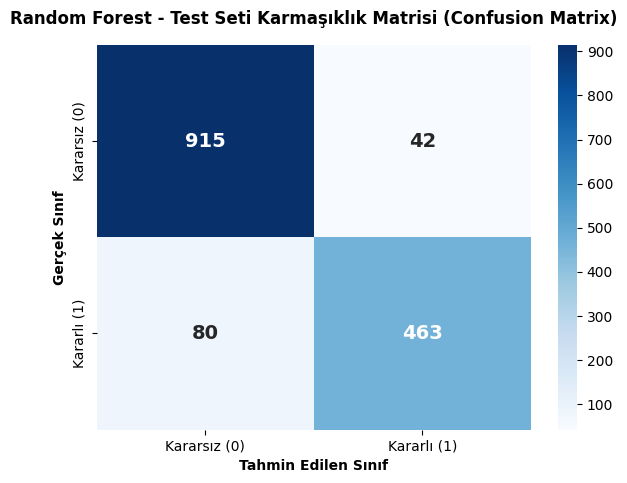

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Adım 14: Hiperparametre Ayarlama (Grid Search)
# ==========================================
print("--- Adım 14: Random Forest için Hiperparametre Optimizasyonu ---")
# Modelin denemesini istediğimiz parametre kombinasyonları (Grid)
param_grid = {
    'n_estimators': [100, 200],       # Ağaç sayısı
    'max_depth': [None, 10, 20],      # Maksimum derinlik
    'min_samples_split': [2, 5]       # Dallanma için gereken minimum örnek sayısı
}

rf_model = RandomForestClassifier(random_state=42)

# GridSearchCV tanımlama (3 katlı çapraz doğrulama ile)
# n_jobs=-1 parametresi Colab'daki tüm işlemcileri kullanarak işlemi hızlandırır.
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='accuracy', verbose=1)

# Grid Search'ü eğitim verisi üzerinde çalıştırma
grid_search.fit(X_train, y_train)

en_iyi_rf = grid_search.best_estimator_
print(f"\nBulunan En İyi Parametreler: {grid_search.best_params_}\n")

# ==========================================
# Adım 15: Seçilen Modelin Test Performansı
# ==========================================
print("--- Adım 15: En İyi Modelin Test Seti Üzerinde Değerlendirilmesi ---")
y_test_pred = en_iyi_rf.predict(X_test)

print("Test Seti Metrikleri:")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}\n")

# Confusion Matrix Görselleştirme
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kararsız (0)', 'Kararlı (1)'],
            yticklabels=['Kararsız (0)', 'Kararlı (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Random Forest - Test Seti Karmaşıklık Matrisi (Confusion Matrix)', fontweight='bold', pad=15)
plt.xlabel('Tahmin Edilen Sınıf', fontweight='bold')
plt.ylabel('Gerçek Sınıf', fontweight='bold')
plt.show()

--- Adım 17 (Bonus): SHAP ile Model Açıklanabilirliği ---


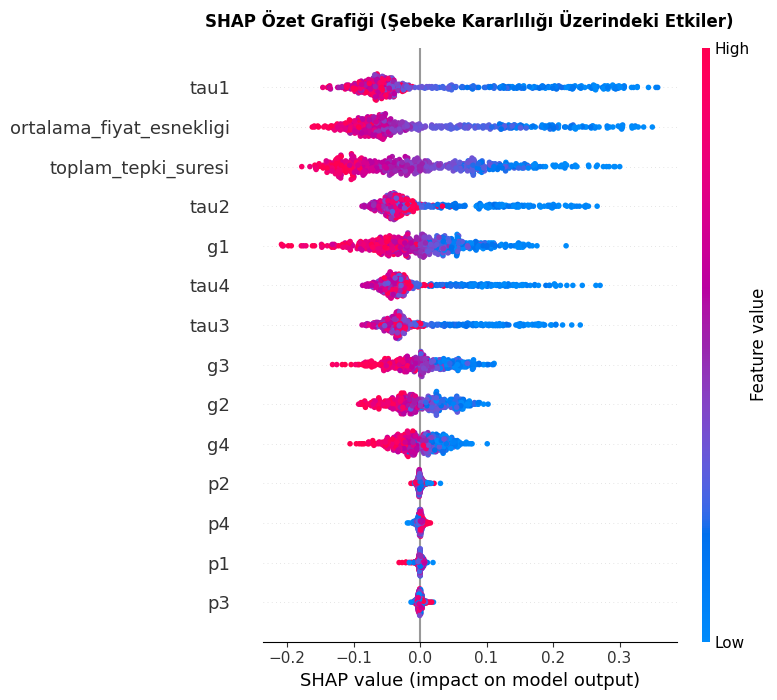

In [6]:
# ==========================================
# Adım 17: Bonus - SHAP ile Model Açıklanabilirliği (Explainability)
# ==========================================
print("--- Adım 17 (Bonus): SHAP ile Model Açıklanabilirliği ---")
import shap
import matplotlib.pyplot as plt

# Hesaplama performansını artırmak için test setinden rastgele 500 örnek alıyoruz
X_test_sample = X_test.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(en_iyi_rf)

# SHAP değerlerini hesapla
shap_values = explainer.shap_values(X_test_sample)

# SHAP kütüphanesinin güncel sürümlerine (0.52+) uyum sağlamak için:
# Pozitif sınıf (Kararlı/1) değerlerini matris tipine göre güvenli bir şekilde alıyoruz
if isinstance(shap_values, list):
    shap_degerleri_sinif1 = shap_values[1]
else:
    shap_degerleri_sinif1 = shap_values[:, :, 1]

# Sınıf 1 (Kararlı / Stable) için SHAP özet grafiği
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_degerleri_sinif1, X_test_sample, show=False)
plt.title("SHAP Özet Grafiği (Şebeke Kararlılığı Üzerindeki Etkiler)", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

--- Korelasyon Matrisi Çiziliyor ---


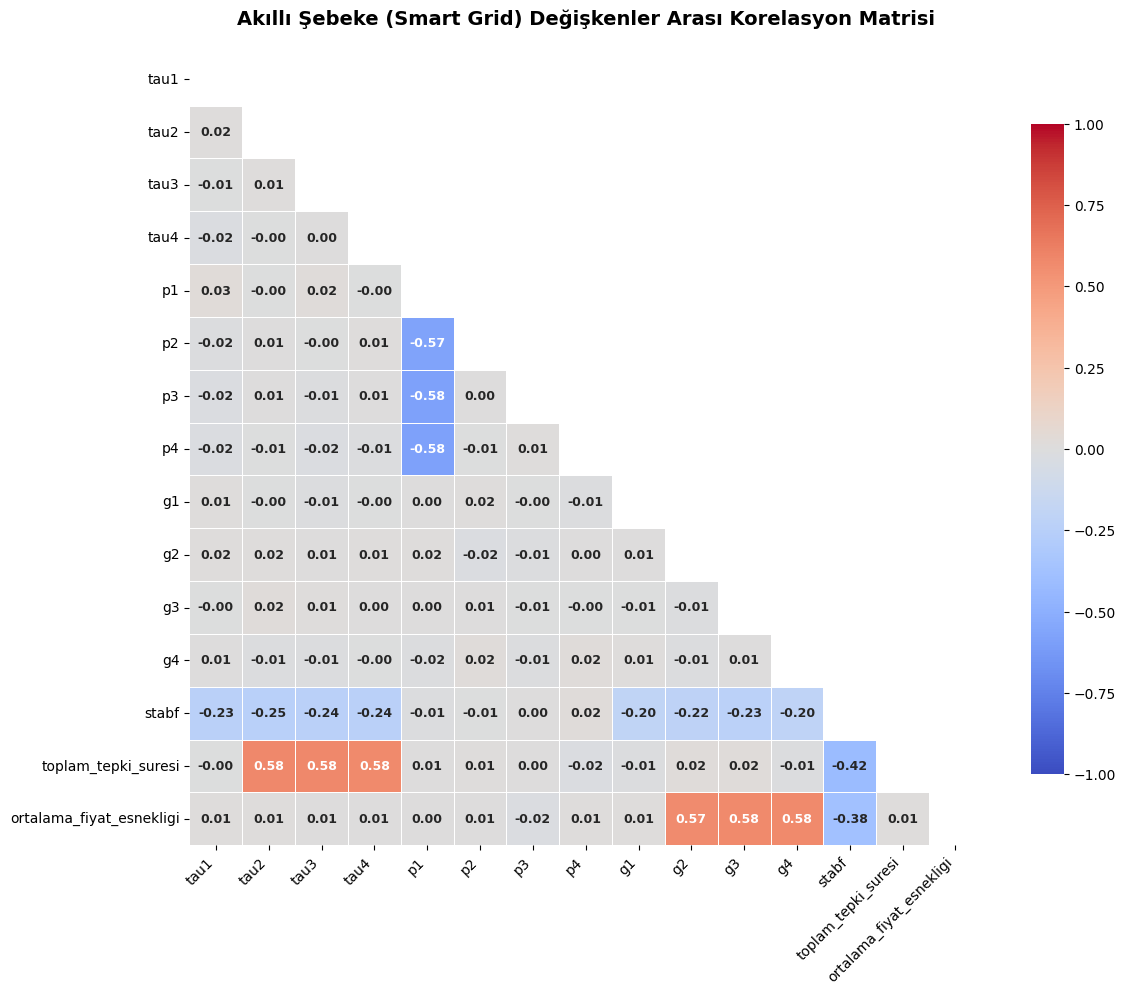

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Ekstra Görselleştirme: Korelasyon Matrisi (Heatmap)
# ==========================================
print("--- Korelasyon Matrisi Çiziliyor ---")

# Görsel boyutunu ayarlıyoruz
plt.figure(figsize=(12, 10))

# Sayısal sütunlar arasındaki korelasyon matrisini hesaplıyoruz
korelasyon_matrisi = df.corr()

# Matrisin üst üçgenini maskeleyerek (tekrar eden kısımları gizleyerek) daha şık görünmesini sağlıyoruz
mask = np.triu(np.ones_like(korelasyon_matrisi, dtype=bool))

# Isı haritasını (Heatmap) çizdiriyoruz
sns.heatmap(korelasyon_matrisi, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.7,
            cbar_kws={"shrink": .8}, annot_kws={"size": 9, "weight": "bold"})

# Başlık ve eksen ayarları
plt.title('Akıllı Şebeke (Smart Grid) Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Grafiği Colab ekranında göster
plt.show()

--- Pairplot Grafiği Çiziliyor ---


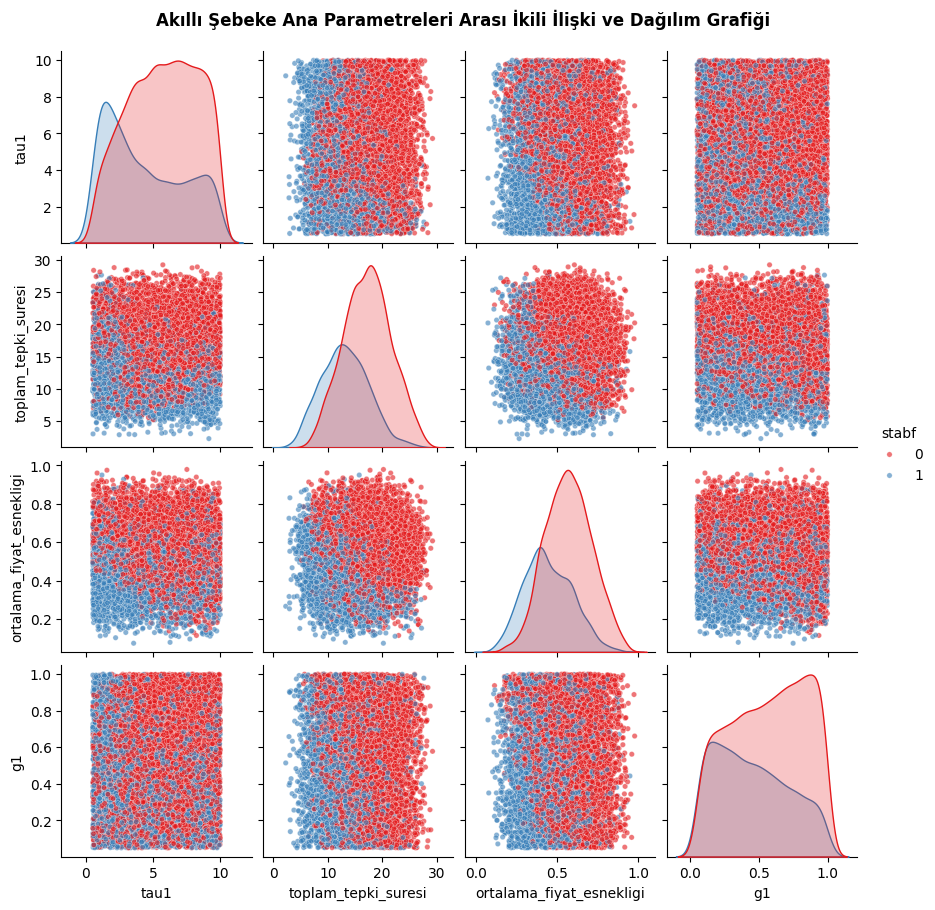

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Ekstra Görselleştirme: Pairplot (Özellikler Arası İlişki)
# ==========================================
print("--- Pairplot Grafiği Çiziliyor ---")

# Görselin daha temiz ve okunabilir olması için en kritik 4 sütunu ve hedef değişkeni seçiyoruz
secilen_sutunlar = ['tau1', 'toplam_tepki_suresi', 'ortalama_fiyat_esnekligi', 'g1', 'stabf']

# Seaborn pairplot fonksiyonu (Hue hedef değişkenimiz stabf oluyor: 0 ve 1)
# diag_kind='kde' ile köşegendeki dağılımları eğri (yoğunluk) olarak çizdiriyoruz
g = sns.pairplot(df[secilen_sutunlar], hue='stabf', palette='Set1',
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 15}, height=2.2)

# Başlık ekleme (y parametresi başlığın grafiğin ne kadar üzerinde duracağını ayarlar)
g.fig.suptitle("Akıllı Şebeke Ana Parametreleri Arası İkili İlişki ve Dağılım Grafiği", y=1.03, fontsize=12, fontweight='bold')

# Grafiği kaydetmek istersen aşağıdaki satırın başındaki '#' işaretini kaldırabilirsin
# plt.savefig('smart_grid_pairplot.png', dpi=300, bbox_inches='tight')

# Grafiği Colab ekranında göster
plt.show()

--- Feature Importance (Öznitelik Önem Dereceleri) Grafiği Çiziliyor ---


/tmp/ipykernel_2683/754251424.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem_Derecesi', y='Öznitelik', data=onem_df_gorsel, palette='viridis')


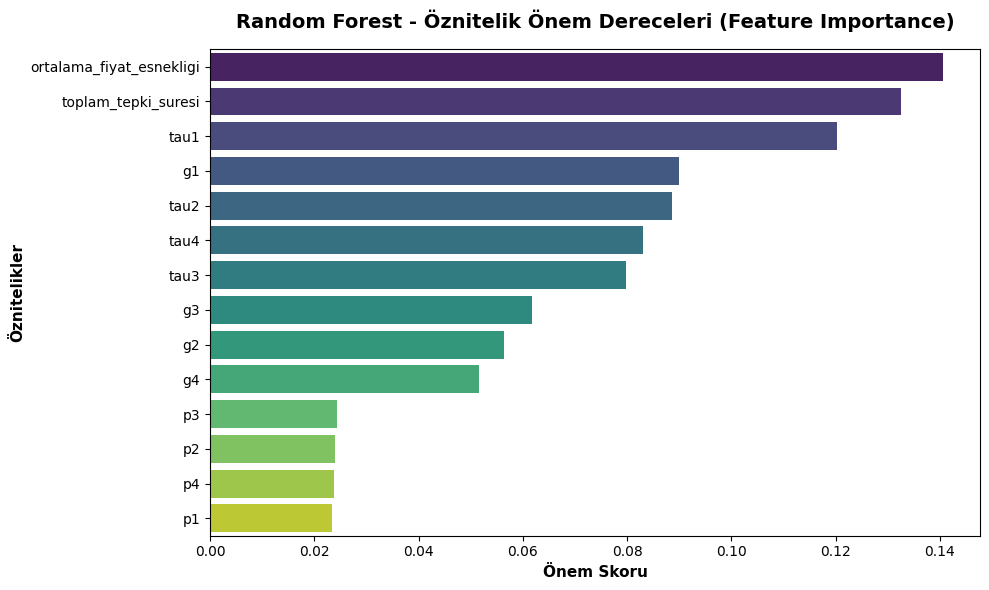

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# Ekstra Görselleştirme: Feature Importance Bar Plot
# ==========================================
print("--- Feature Importance (Öznitelik Önem Dereceleri) Grafiği Çiziliyor ---")

# Grid Search ile bulduğumuz en iyi modelin özellik önemlerini alıyoruz
onem_skorlari = en_iyi_rf.feature_importances_

# Özellikleri ve önem skorlarını bir DataFrame'de birleştirip büyükten küçüğe sıralıyoruz
onem_df_gorsel = pd.DataFrame({
    'Öznitelik': X.columns,
    'Önem_Derecesi': onem_skorlari
}).sort_values(by='Önem_Derecesi', ascending=False)

# Grafik boyutunu ayarlıyoruz
plt.figure(figsize=(10, 6))

# Yatay çubuk grafiğini (Horizontal Bar Plot) çizdiriyoruz
sns.barplot(x='Önem_Derecesi', y='Öznitelik', data=onem_df_gorsel, palette='viridis')

# Başlık ve eksen isimlendirmeleri
plt.title('Random Forest - Öznitelik Önem Dereceleri (Feature Importance)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Önem Skoru', fontsize=11, fontweight='bold')
plt.ylabel('Öznitelikler', fontsize=11, fontweight='bold')

plt.tight_layout()

# Grafiği kaydetmek istersen aşağıdaki satırın başındaki '#' işaretini kaldırabilirsin
# plt.savefig('smart_grid_feature_importance.png', dpi=300, bbox_inches='tight')

# Grafiği Colab ekranında göster
plt.show()

--- ROC Eğrisi Çiziliyor ---


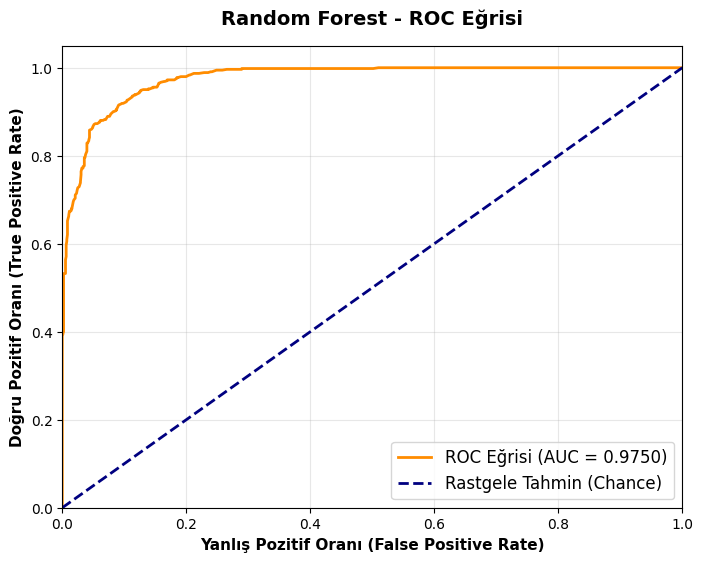

In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ==========================================
# Ekstra Görselleştirme: ROC Eğrisi ve AUC
# ==========================================
print("--- ROC Eğrisi Çiziliyor ---")

# Test seti için modelin tahmin olasılıklarını (probabilities) alıyoruz
# Sadece pozitif sınıfın (1 - Kararlı) olasılıklarını seçiyoruz
y_test_pred_prob = en_iyi_rf.predict_proba(X_test)[:, 1]

# ROC eğrisi için FPR (False Positive Rate), TPR (True Positive Rate) ve threshold değerlerini hesaplıyoruz
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob)

# AUC (Eğri Altında Kalan Alan) skorunu hesaplıyoruz
roc_auc = auc(fpr, tpr)

# Görselleştirme ayarları
plt.figure(figsize=(8, 6))

# ROC eğrisini çizdiriyoruz
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')

# Rastgele tahmin çizgisini (şans eseri) çizdiriyoruz (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin (Chance)')

# Eksen ve başlık ayarları
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)', fontsize=11, fontweight='bold')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)', fontsize=11, fontweight='bold')
plt.title('Random Forest - ROC Eğrisi', fontsize=14, fontweight='bold', pad=15)

# Lejantı (Gösterge) sağ alt köşeye yerleştiriyoruz
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# Grafiği kaydetmek istersen aşağıdaki satırın başındaki '#' işaretini kaldırabilirsin
# plt.savefig('smart_grid_roc_curve.png', dpi=300, bbox_inches='tight')

# Grafiği göster
plt.show()